### Installing dependencies for `daa233/generative-inpainting-pytorch`

In [1]:
# Install PyTorch and Torchvision
# Colab usually has a recent PyTorch version pre-installed, but we can ensure a compatible version.
# If you need a specific CUDA version, you might adjust the command from pytorch.org
!pip install torch>=1.0 torchvision>=0.2.0

In [2]:
# Install tensorboardX
!pip install tensorboardX

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.5/87.5 kB 5.1 MB/s eta 0:00:00


In [3]:
# Install pyyaml
!pip install pyyaml

All listed dependencies should now be installed. You can now proceed with cloning the repository and trying to run its code.

### Cloning the `daa233/generative-inpainting-pytorch` repository

In [4]:
!git clone https://github.com/daa233/generative-inpainting-pytorch.git
%cd generative-inpainting-pytorch

Cloning into 'generative-inpainting-pytorch'...
remote: Enumerating objects: 142, done.
remote: Counting objects: 100% (52/52), done.
remote: Compressing objects: 100% (26/26), done.
remote: Total 142 (delta 35), reused 26 (delta 26), pack-reused 90 (from 1)
Receiving objects: 100% (142/142), 1.66 MiB | 23.64 MiB/s, done.
Resolving deltas: 100% (59/59), done.
/content/generative-inpainting-pytorch


The repository should now be cloned and your current directory set to `generative-inpainting-pytorch`. You can now explore the files and try running some of the project's scripts, such as `test.py` or `train.py`.

In [8]:
# Fix PyYAML TypeError: load() missing 1 required positional argument: 'Loader'
# This occurs because newer versions of PyYAML require an explicit Loader for security.
# We will patch the `utils/tools.py` file to include `FullLoader`.
# !sed -i '/^import yaml$/a from yaml import FullLoader' /content/generative-inpainting-pytorch/utils/tools.py
# !sed -i 's/return yaml.load(stream)/return yaml.load(stream, Loader=FullLoader)/g' /content/generative-inpainting-pytorch/utils/tools.py

# # Fix 'Invalid device id' error by reducing the number of requested GPUs to 1 (device 0)
# # This directly patches the config file for subsequent runs/imports.
# !sed -i 's/gpu_ids: \[0, 1, 2\]/gpu_ids: \[0\]/g' /content/generative-inpainting-pytorch/configs/config.yaml

# # Create the results directory if it doesn't exist
# !mkdir -p results

# The original test_single.py command is commented out as we are moving to an optimized batch processing approach.
# !python test_single.py \
#     --image examples/imagenet/imagenet_patches_ILSVRC2012_val_00000827_input.png \
#     --mask examples/center_mask_256.png \
#     --output results/inpaint_output.png \
#     --config configs/config.yaml \
#     --checkpoint_path .

Arguments: Namespace(config='configs/config.yaml', seed=None, image='examples/imagenet/imagenet_patches_ILSVRC2012_val_00000827_input.png', mask='examples/center_mask_256.png', output='results/inpaint_output.png', flow='', checkpoint_path='.', iter=0)
Random seed: 1617
Configuration: {'dataset_name': 'imagenet', 'data_with_subfolder': True, 'train_data_path': '/media/ouc/4T_A/datasets/ImageNet/ILSVRC2012_img_train/', 'val_data_path': None, 'resume': None, 'batch_size': 48, 'image_shape': [256, 256, 3], 'mask_shape': [128, 128], 'mask_batch_same': True, 'max_delta_shape': [32, 32], 'margin': [0, 0], 'discounted_mask': True, 'spatial_discounting_gamma': 0.9, 'random_crop': True, 'mask_type': 'hole', 'mosaic_unit_size': 12, 'expname': 'benchmark', 'cuda': True, 'gpu_ids': [0], 'num_workers': 4, 'lr': 0.0001, 'beta1': 0.5, 'beta2': 0.9, 'n_critic': 5, 'niter': 500000, 'print_iter': 100, 'viz_iter': 1000, 'viz_max_out': 16, 'snapshot_save_iter': 5000, 'coarse_l1_alpha': 1.2, 'l1_loss_alpha'

In [11]:
import os
os.system(f'unzip -q /content/generative-inpainting-pytorch/PlacesTestSet.zip -d /content/generative-inpainting-pytorch/')
os.system(f'unzip -q /content/generative-inpainting-pytorch/masks_variety_for_iizuka.zip -d /content/generative-inpainting-pytorch/')

0

In [ ]:
import os
import torchvision.transforms as transforms
import torchvision.utils as vutils

# Definisci i percorsi
original_mask_dir = "/content/generative-inpainting-pytorch/masks_variety_for_iizuka"
inverted_mask_dir = "/content/generative-inpainting-pytorch/masks_inverted"
os.makedirs(inverted_mask_dir, exist_ok=True)

# Elenca le maschere originali
raw_mask_list = sorted([f for f in os.listdir(original_mask_dir)
                        if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp'))])

for mask_name in raw_mask_list:
    mask_path = os.path.join(original_mask_dir, mask_name)

    mask_raw = Image.open(mask_path).convert('RGB')

    mask_tensor = transforms.ToTensor()(mask_raw)[0:1, :, :]

    mask_inverted = 1. - mask_tensor

    # 4. Salva la nuova maschera nella cartella di output
    out_path = os.path.join(inverted_mask_dir, mask_name)
    vutils.save_image(mask_inverted, out_path, padding=0)

print(f"Masks inverted (masked part is white): {inverted_mask_dir}")

In [44]:
import os
import glob
import random
from argparse import ArgumentParser

import torch
import torch.nn as nn
import torch.backends.cudnn as cudnn
import torchvision.transforms as transforms
import torchvision.utils as vutils
from PIL import Image

from model.networks import Generator
from utils.tools import get_config, mask_image, is_image_file, default_loader, normalize, get_model_list

config = get_config('configs/config.yaml')
config["image_shape"] = [256, 256, 3]
config["mask_shape"] = [256, 256]

if torch.cuda.is_available() and config['cuda']:
    # gpu_ids is already patched to [0] in config.yaml by the previous cell's sed command
    device = torch.device(f'cuda:{config["gpu_ids"][0]}')
    print(f"Using GPU device: {device}")
else:
    device = torch.device('cpu')
    print(f"CUDA not available or disabled in config. Using CPU device.")

# CUDA configuration
cuda = config['cuda']
device_ids = config['gpu_ids']
if cuda:
    os.environ['CUDA_VISIBLE_DEVICES'] = ','.join(str(i) for i in device_ids)
    device_ids = list(range(len(device_ids)))
    config['gpu_ids'] = device_ids
    cudnn.benchmark = True

netG = Generator(config['netG'], cuda, device_ids)
last_model_name = "/content/generative-inpainting-pytorch/gen_00430000.pt"
netG.load_state_dict(torch.load(last_model_name))

netG.to(device)
netG.eval() # Set to evaluation

input_dir = "/content/generative-inpainting-pytorch/PlacesTestSet"
mask_dir = "/content/generative-inpainting-pytorch/masks_inverted"

image_list = sorted([f for f in os.listdir(input_dir)
                     if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp'))])

# Masks MUST have the masked portion white (=1 in grayscale)
mask_list = sorted([f for f in os.listdir(mask_dir)
                    if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp'))])

output_dir = "/content/ContextAttentionOutput"
os.makedirs(output_dir, exist_ok=True)

counter = 0

with torch.no_grad():
  for img_name in image_list:
    img_path = os.path.join(input_dir, img_name)
    x = default_loader(img_path)
    x = transforms.Resize(config['image_shape'][:-1])(x)
    x = transforms.CenterCrop(config['image_shape'][:-1])(x)
    x = transforms.ToTensor()(x)
    x = normalize(x)
    for mask_name in mask_list:
      mask_path = os.path.join(mask_dir, mask_name)
      mask = default_loader(mask_path)
      mask = transforms.Resize(config['image_shape'][:-1])(mask)
      mask = transforms.CenterCrop(config['image_shape'][:-1])(mask)
      mask = transforms.ToTensor()(mask)[0].unsqueeze(dim=0)
      x_in = x * (1. - mask)
      x_in = x_in.unsqueeze(dim=0).to(device)
      mask = mask.unsqueeze(dim=0).to(device)

      # Inference
      x1, x2, offset_flow = netG(x_in, mask)
      inpainted_result = x2 * mask + x_in * (1. - mask)

      img_base = os.path.splitext(img_name)[0]
      mask_base = os.path.splitext(mask_name)[0]

      out_name = "{}__{}.png".format(img_base, mask_base)
      out_path = os.path.join(output_dir, out_name)

      vutils.save_image(inpainted_result, out_path, padding=0, normalize=True)

      counter += 1
      if (counter % 100 == 0): print(f"Processed {counter} images.")

Using GPU device: cuda:0
Processed 100 images.
Processed 200 images.
Processed 300 images.
Processed 400 images.
Processed 500 images.
Processed 600 images.
Processed 700 images.
Processed 800 images.
Processed 900 images.
Processed 1000 images.
Processed 1100 images.
Processed 1200 images.
Processed 1300 images.
Processed 1400 images.
Processed 1500 images.
Processed 1600 images.
Processed 1700 images.
Processed 1800 images.
Processed 1900 images.
Processed 2000 images.
Processed 2100 images.
Processed 2200 images.
Processed 2300 images.
Processed 2400 images.
Processed 2500 images.
Processed 2600 images.
Processed 2700 images.
Processed 2800 images.
Processed 2900 images.
Processed 3000 images.
Processed 3100 images.
Processed 3200 images.
Processed 3300 images.
Processed 3400 images.
Processed 3500 images.
Processed 3600 images.
Processed 3700 images.
Processed 3800 images.
Processed 3900 images.
Processed 4000 images.
Processed 4100 images.
Processed 4200 images.
Processed 4300 ima

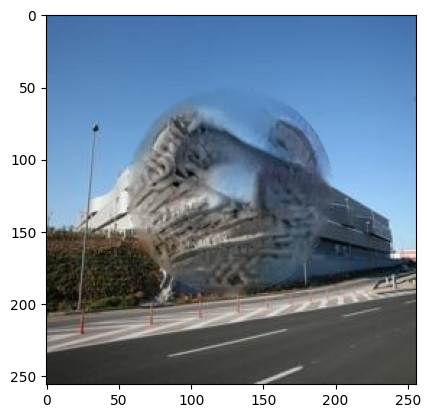

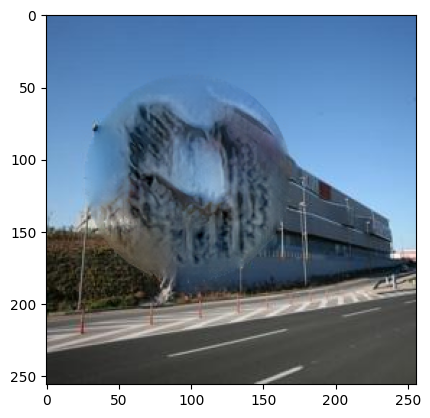

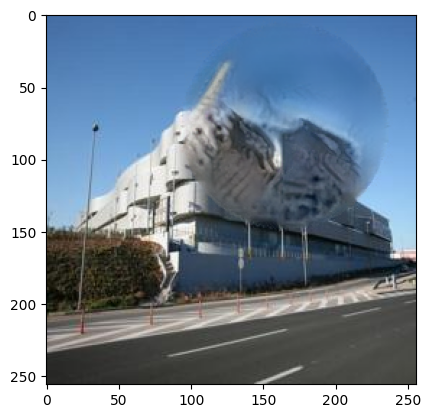

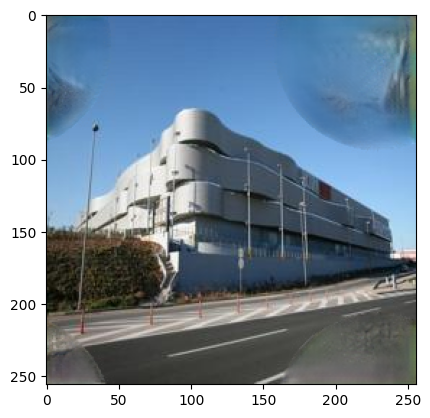

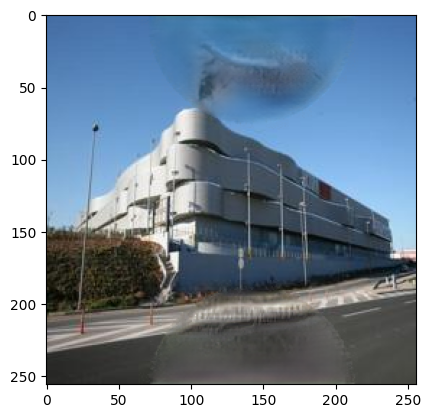

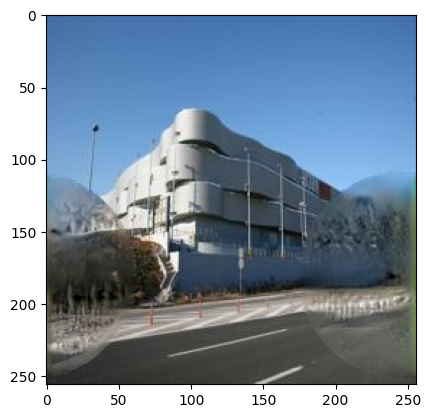

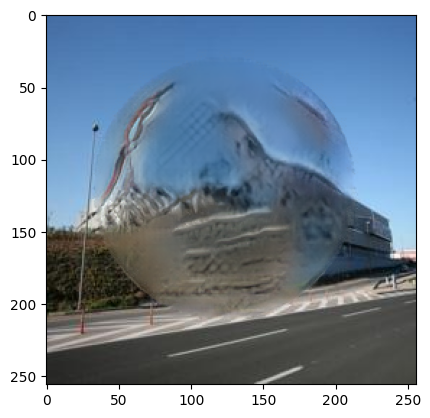

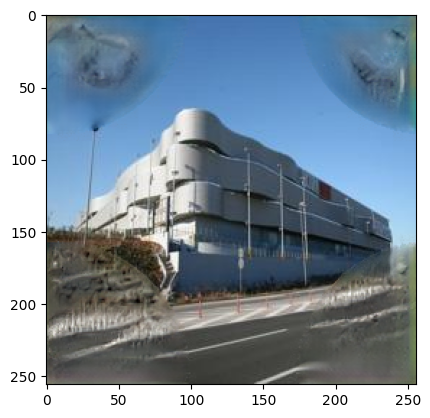

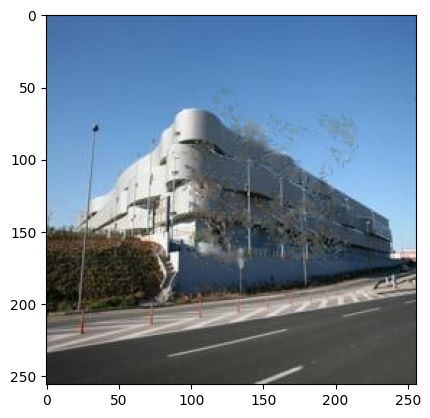

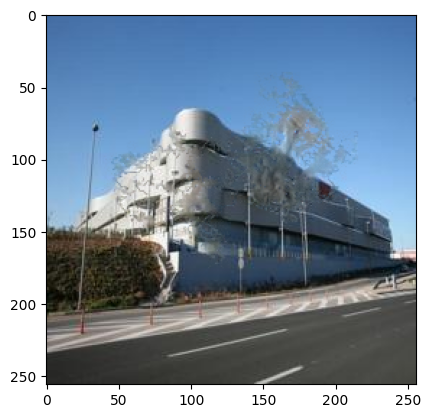

In [45]:
import matplotlib.pyplot as plt
output_list = sorted([f for f in os.listdir(output_dir)
                     if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp'))])
output_test = output_list[30:40]
for out in output_test:
  out_path = os.path.join(output_dir, out)
  img = Image.open(out_path).convert('RGB')
  plt.imshow(img)
  plt.show()